In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv('ecommerce_dataset_updated.csv')  # Change filename if different

# Basic exploration
print("=" * 60)
print("E-COMMERCE DATASET EXPLORATION")
print("=" * 60)

print("\n1. DATASET SHAPE")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n2. COLUMN NAMES")
print(df.columns.tolist())

print("\n3. FIRST 5 ROWS")
print(df.head())

print("\n4. DATA TYPES")
print(df.dtypes)

print("\n5. MISSING VALUES")
print(df.isnull().sum())

print("\n6. BASIC STATS")
print(df.describe())

E-COMMERCE DATASET EXPLORATION

1. DATASET SHAPE
Rows: 3660
Columns: 8

2. COLUMN NAMES
['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date']

3. FIRST 5 ROWS
    User_ID  Product_ID  Category  Price (Rs.)  Discount (%)  \
0  337c166f  f414122f-e    Sports        36.53            15   
1  d38a19bf  fde50f9c-5  Clothing       232.79            20   
2  d7f5f0b0  0d96fc90-3    Sports       317.02            25   
3  395d4994  964fc44b-d      Toys       173.19            25   
4  a83c145c  d70e2fc6-e    Beauty       244.80            20   

   Final_Price(Rs.) Payment_Method Purchase_Date  
0             31.05    Net Banking    12-11-2024  
1            186.23    Net Banking    09-02-2024  
2            237.76    Credit Card    01-09-2024  
3            129.89            UPI    01-04-2024  
4            195.84    Net Banking    27-09-2024  

4. DATA TYPES
User_ID              object
Product_ID           object
Category 

In [ ]:
# Check before cleaning
print("BEFORE CLEANING:")
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}\n")

# CLEANING

# 1. Remove duplicates (generic step, can be kept)
df = df.drop_duplicates()

# The following steps are adapted to the current dataset's column names:

# 2. Convert Purchase_Date to datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format='%d-%m-%Y')

# 3. Create useful columns from Purchase_Date
df['Purchase_Year'] = df['Purchase_Date'].dt.year
df['Purchase_Month'] = df['Purchase_Date'].dt.month
df['Purchase_Day'] = df['Purchase_Date'].dt.day

# Removed: Steps related to 'Quantity', 'UnitPrice', 'InvoiceNo', 'InvoiceDate', and 'TotalSales'
# as these columns are not present in the 'ecommerce_dataset_updated.csv' dataset.
# Also removed 'dropna' on specific columns as there were no missing values initially.
# And removed negative/zero quantity/price checks as 'Quantity' and 'UnitPrice' don't exist.

print("AFTER CLEANING:")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\n✓ Data cleaned successfully!")

BEFORE CLEANING:
Total rows: 3660
Missing values:
User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

AFTER CLEANING:
Total rows: 3660
Columns: ['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date', 'Purchase_Year', 'Purchase_Month', 'Purchase_Day']

✓ Data cleaned successfully!


In [ ]:
print("=" * 70)
print("E-COMMERCE SALES ANALYSIS")
print("=" * 70)

# 1. BUSINESS OVERVIEW
print("\n1. BUSINESS METRICS")
print("-" * 70)
# Use 'Final_Price(Rs.)' for revenue as 'TotalSales' does not exist
total_revenue = df['Final_Price(Rs.)'].sum()
# Since there is no 'InvoiceNo' or specific order identifier,
# we consider each row as an individual purchase transaction.
total_purchases = len(df) # Counting each row as a purchase/transaction
total_customers = df['User_ID'].nunique() # Use 'User_ID' instead of 'CustomerID'
avg_purchase_value = total_revenue / total_purchases # Average value per individual purchase

print(f"Total Revenue: Rs. {total_revenue:,.2f}")
print(f"Total Individual Purchases: {total_purchases:,}")
print(f"Total Unique Customers: {total_customers:,}")
print(f"Average Purchase Value: Rs. {avg_purchase_value:,.2f}")

# 2. TOP 10 PRODUCTS BY REVENUE
print("\n2. TOP 10 PRODUCTS BY REVENUE")
print("-" * 70)
# Use 'Product_ID' and 'Final_Price(Rs.)'
top_products_by_revenue = df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
print(top_products_by_revenue)

# 3. TOP 10 CUSTOMERS BY SPENDING
print("\n3. TOP 10 CUSTOMERS BY SPENDING")
print("-" * 70)
# Use 'User_ID' and 'Final_Price(Rs.)'
top_customers_by_spending = df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
print(top_customers_by_spending)

# 4. MONTHLY REVENUE
print("\n4. REVENUE BY MONTH")
print("-" * 70)
# Use 'Purchase_Month' and 'Final_Price(Rs.)'
monthly_revenue = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
print(monthly_revenue)

# 5. TOP 10 PRODUCTS BY COUNT OF PURCHASES (as 'Quantity' is not available)
print("\n5. TOP 10 PRODUCTS BY COUNT OF PURCHASES")
print("-" * 70)
# Use 'Product_ID' and count occurrences as 'Quantity' column is not present
top_products_by_count = df['Product_ID'].value_counts().head(10)
print(top_products_by_count)

# 6. CUSTOMER ANALYSIS (SPENDING STATISTICS)
print("\n6. CUSTOMER SPENDING STATISTICS")
print("-" * 70)
customer_spending = df.groupby('User_ID')['Final_Price(Rs.)'].sum()
print(f"Average customer spending: Rs. {customer_spending.mean():,.2f}")
print(f"Max customer spending: Rs. {customer_spending.max():,.2f}")
print(f"Min customer spending: Rs. {customer_spending.min():,.2f}")

E-COMMERCE SALES ANALYSIS

1. BUSINESS METRICS
----------------------------------------------------------------------
Total Revenue: Rs. 757,278.08
Total Individual Purchases: 3,660
Total Unique Customers: 3,660
Average Purchase Value: Rs. 206.91

2. TOP 10 PRODUCTS BY REVENUE
----------------------------------------------------------------------
Product_ID
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
128bb94a-4    487.06
28714133-6    486.79
585b0773-2    484.56
3be497cb-0    480.49
6390f2ea-8    479.63
Name: Final_Price(Rs.), dtype: float64

3. TOP 10 CUSTOMERS BY SPENDING
----------------------------------------------------------------------
User_ID
8b885340    496.82
20797b76    495.02
d8970dd2    493.04
da7bc76a    492.41
68722b9b    491.70
05e6557c    487.06
67abda0a    486.79
d646700c    484.56
edb89577    480.49
f9e89622    479.63
Name: Final_Price(Rs.), dtype: float64

4. REVENUE BY MONTH
-----------------------------

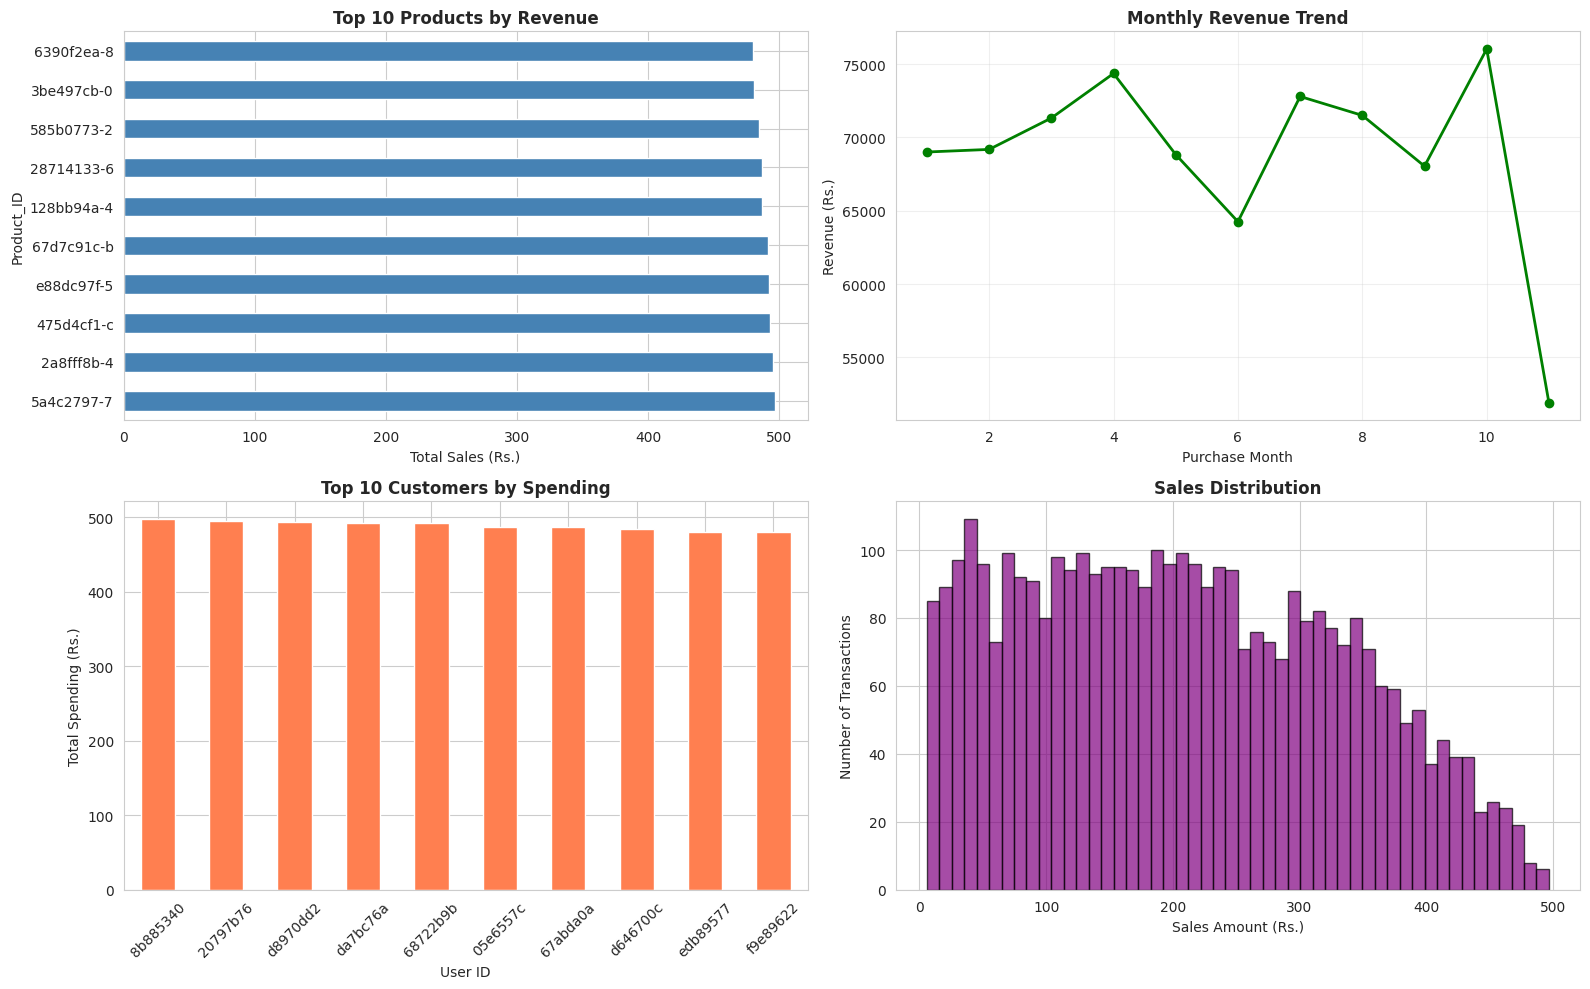

✓ Dashboard created!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create dashboard with 4 charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CHART 1: Top 10 Products by Revenue
ax1 = axes[0, 0]
top_products = df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 10 Products by Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Sales (Rs.)')

# CHART 2: Monthly Revenue Trend
ax2 = axes[0, 1]
monthly = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
monthly.plot(kind='line', ax=ax2, color='green', marker='o', linewidth=2)
ax2.set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Purchase Month')
ax2.set_ylabel('Revenue (Rs.)')
ax2.grid(True, alpha=0.3)

# CHART 3: Top 10 Customers
ax3 = axes[1, 0]
top_customers = df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar', ax=ax3, color='coral')
ax3.set_title('Top 10 Customers by Spending', fontsize=12, fontweight='bold')
ax3.set_xlabel('User ID')
ax3.set_ylabel('Total Spending (Rs.)')
ax3.tick_params(axis='x', rotation=45)

# CHART 4: Sales Distribution
ax4 = axes[1, 1]
ax4.hist(df['Final_Price(Rs.)'], bins=50, color='purple', edgecolor='black', alpha=0.7)
ax4.set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sales Amount (Rs.)')
ax4.set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('ecommerce_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Dashboard created!")

In [ ]:
# Save cleaned dataset
df.to_csv('cleaned_ecommerce_data.csv', index=False)

# Save insights to text file
insights = f"""
E-COMMERCE SALES ANALYSIS REPORT
=====================================

BUSINESS METRICS:
- Total Revenue: Rs. {df['Final_Price(Rs.)'].sum():,.2f}
- Total Individual Purchases: {len(df):,}
- Total Unique Customers: {df['User_ID'].nunique():,}
- Avg Purchase Value: Rs. {df['Final_Price(Rs.)'].sum() / len(df):,.2f}

TOP PRODUCT: {df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).index[0]}

TOP CUSTOMER: User ID {df.groupby('User_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).index[0]}

Monthly Revenue Trend:
{df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().to_string()}
"""

with open('sales_insights.txt', 'w') as f:
    f.write(insights)

print("✓ Files saved!")

# Now click **Files icon** (left sidebar) -> **Download** your files:
# - `cleaned_ecommerce_data.csv`
# - `ecommerce_dashboard.png`
# - `sales_insights.txt`

# Takes: 5 minutes

# ---

## **QUICK COLAB TIPS**

# **To add new cell:** Click **+ Code** button
# **To run cell:** Click Play button or press `Ctrl+Enter`
# **To see output:** Results show below the cell
# **Upload file:** Files icon -> Upload
# **Download file:** Right-click file -> Download

# ---

## **YOUR COLAB NOTEBOOK STRUCTURE**
# ```
# Cell 1: Import & Explore Data
# Cell 2: Clean Data
# Cell 3: Analysis & Insights
# Cell 4: Create Visualizations
# Cell 5: Save Files
# ```

✓ Files saved!


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv('ecommerce_dataset_updated.csv')  # Change if your filename is different

# Basic exploration
print("=" * 60)
print("E-COMMERCE DATASET EXPLORATION")
print("=" * 60)

print("\n1. DATASET SHAPE")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n2. COLUMN NAMES")
print(df.columns.tolist())

print("\n3. FIRST 5 ROWS")
print(df.head())

print("\n4. DATA TYPES")
print(df.dtypes)

print("\n5. MISSING VALUES")
print(df.isnull().sum())

print("\n6. BASIC STATS")
print(df.describe())

E-COMMERCE DATASET EXPLORATION

1. DATASET SHAPE
Rows: 3660
Columns: 8

2. COLUMN NAMES
['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date']

3. FIRST 5 ROWS
    User_ID  Product_ID  Category  Price (Rs.)  Discount (%)  \
0  337c166f  f414122f-e    Sports        36.53            15   
1  d38a19bf  fde50f9c-5  Clothing       232.79            20   
2  d7f5f0b0  0d96fc90-3    Sports       317.02            25   
3  395d4994  964fc44b-d      Toys       173.19            25   
4  a83c145c  d70e2fc6-e    Beauty       244.80            20   

   Final_Price(Rs.) Payment_Method Purchase_Date  
0             31.05    Net Banking    12-11-2024  
1            186.23    Net Banking    09-02-2024  
2            237.76    Credit Card    01-09-2024  
3            129.89            UPI    01-04-2024  
4            195.84    Net Banking    27-09-2024  

4. DATA TYPES
User_ID              object
Product_ID           object
Category 

In [ ]:
# Check data BEFORE cleaning
print("=" * 60)
print("BEFORE CLEANING")
print("=" * 60)
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}\n")

# ===== CLEANING STARTS =====

# 1. Remove duplicate rows (generic step, can be kept)
df = df.drop_duplicates()

# The following steps are adapted to the current dataset's column names:

# 2. Convert Purchase_Date to datetime format
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format='%d-%m-%Y')

# 3. Create new useful columns from Purchase_Date
df['Purchase_Year'] = df['Purchase_Date'].dt.year
df['Purchase_Month'] = df['Purchase_Date'].dt.month
df['Purchase_Day'] = df['Purchase_Date'].dt.day

# Removed: Steps related to 'Quantity', 'UnitPrice', 'InvoiceNo', 'InvoiceDate', and 'TotalSales'
# as these columns are not present in the 'ecommerce_dataset_updated.csv' dataset.
# Also removed 'dropna' on specific columns as there were no missing values initially,
# and negative/zero quantity/price checks as 'Quantity' and 'UnitPrice' don't exist.

# Check data AFTER cleaning
print("=" * 60)
print("AFTER CLEANING")
print("=" * 60)
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\n✓ Data cleaned successfully!")

BEFORE CLEANING
Total rows: 3660
Missing values:
User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

AFTER CLEANING
Total rows: 3660
Columns: ['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date', 'Purchase_Year', 'Purchase_Month', 'Purchase_Day']

✓ Data cleaned successfully!


In [ ]:
print("=" * 70)
print("E-COMMERCE SALES ANALYSIS")
print("=" * 70)

# 1. BUSINESS OVERVIEW
print("\n1. BUSINESS METRICS")
print("-" * 70)
total_revenue = df['Final_Price(Rs.)'].sum()
total_transactions = len(df)
total_users = df['User_ID'].nunique()
total_products = df['Product_ID'].nunique()
avg_transaction = total_revenue / total_transactions

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_users:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Transaction Value: ₹{avg_transaction:,.2f}")

# 2. TOP 10 CATEGORIES BY REVENUE
print("\n2. TOP 10 CATEGORIES BY REVENUE")
print("-" * 70)
top_categories = df.groupby('Category')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
for idx, (cat, revenue) in enumerate(top_categories.items(), 1):
    print(f"{idx}. {cat}: ₹{revenue:,.2f}")

# 3. TOP 10 PRODUCTS BY REVENUE
print("\n3. TOP 10 PRODUCTS BY REVENUE")
print("-" * 70)
top_products = df.groupby('Product_ID')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(10)
for idx, (prod, revenue) in enumerate(top_products.items(), 1):
    print(f"{idx}. Product {prod}: ₹{revenue:,.2f}")

# 4. DISCOUNT ANALYSIS
print("\n4. DISCOUNT ANALYSIS")
print("-" * 70)
avg_discount = df['Discount (%)'].mean()
max_discount = df['Discount (%)'].max()
min_discount = df['Discount (%)'].min()
print(f"Average Discount: {avg_discount:.2f}%")
print(f"Maximum Discount: {max_discount}%")
print(f"Minimum Discount: {min_discount}%")

# 5. PAYMENT METHOD BREAKDOWN
print("\n5. PAYMENT METHOD BREAKDOWN")
print("-" * 70)
payment_methods = df['Payment_Method'].value_counts()
for method, count in payment_methods.items():
    percentage = (count / len(df)) * 100
    revenue = df[df['Payment_Method'] == method]['Final_Price(Rs.)'].sum()
    print(f"{method}: {count:,} transactions ({percentage:.1f}%) - ₹{revenue:,.2f}")

# 6. MONTHLY SALES TREND
print("\n6. MONTHLY SALES TREND")
print("-" * 70)
monthly_sales = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
for month, sales in monthly_sales.items():
    print(f"Month {month}: ₹{sales:,.2f}")

# 7. CUSTOMER ANALYSIS
print("\n7. CUSTOMER ANALYSIS")
print("-" * 70)
customer_spending = df.groupby('User_ID')['Final_Price(Rs.)'].sum()
print(f"Average customer spending: ₹{customer_spending.mean():,.2f}")
print(f"Highest customer spending: ₹{customer_spending.max():,.2f}")
print(f"Lowest customer spending: ₹{customer_spending.min():,.2f}")

print("\n" + "=" * 70)
print("✓ ANALYSIS COMPLETE!")
print("=" * 70)

E-COMMERCE SALES ANALYSIS

1. BUSINESS METRICS
----------------------------------------------------------------------
Total Revenue: ₹757,278.08
Total Transactions: 3,660
Total Customers: 3,660
Total Products: 3,660
Average Transaction Value: ₹206.91

2. TOP 10 CATEGORIES BY REVENUE
----------------------------------------------------------------------
1. Clothing: ₹115,314.84
2. Books: ₹111,149.35
3. Home & Kitchen: ₹110,328.08
4. Sports: ₹108,518.79
5. Toys: ₹107,289.69
6. Beauty: ₹104,215.10
7. Electronics: ₹100,462.23

3. TOP 10 PRODUCTS BY REVENUE
----------------------------------------------------------------------
1. Product 5a4c2797-7: ₹496.82
2. Product 2a8fff8b-4: ₹495.02
3. Product 475d4cf1-c: ₹493.04
4. Product e88dc97f-5: ₹492.41
5. Product 67d7c91c-b: ₹491.70
6. Product 128bb94a-4: ₹487.06
7. Product 28714133-6: ₹486.79
8. Product 585b0773-2: ₹484.56
9. Product 3be497cb-0: ₹480.49
10. Product 6390f2ea-8: ₹479.63

4. DISCOUNT ANALYSIS
-------------------------------------

/tmp/ipython-input-337/4280577993.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue = df.groupby('Discount_Range')['Final_Price(Rs.)'].sum()


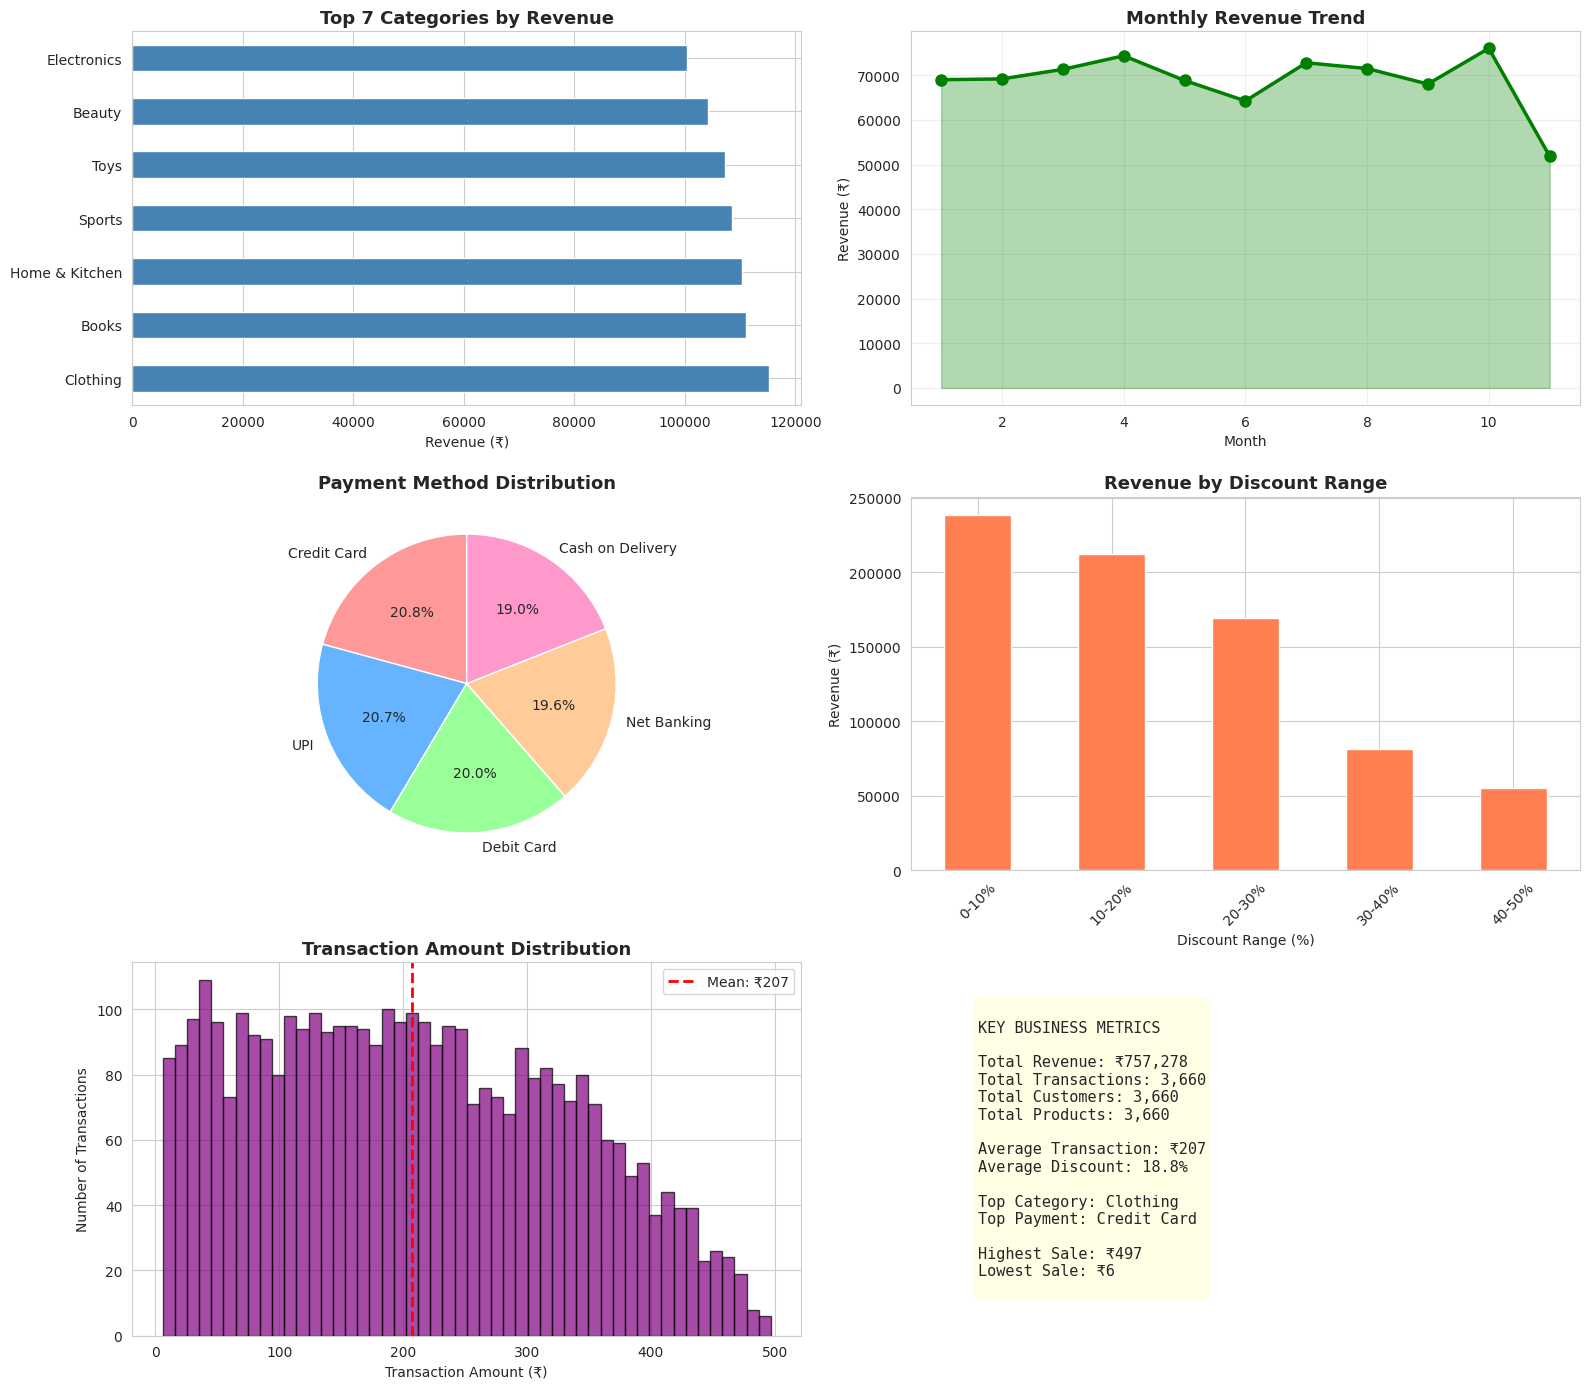

✓ Dashboard created successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create dashboard with 6 charts
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# CHART 1: Top 7 Categories by Revenue
ax1 = axes[0, 0]
top_categories = df.groupby('Category')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(7)
top_categories.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 7 Categories by Revenue', fontsize=13, fontweight='bold')
ax1.set_xlabel('Revenue (₹)')
ax1.set_ylabel('')

# CHART 2: Monthly Revenue Trend
ax2 = axes[0, 1]
monthly = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
ax2.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='green', markersize=8)
ax2.fill_between(monthly.index, monthly.values, alpha=0.3, color='green')
ax2.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue (₹)')
ax2.grid(True, alpha=0.3)

# CHART 3: Payment Method Distribution
ax3 = axes[1, 0]
payment = df['Payment_Method'].value_counts()
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
ax3.pie(payment.values, labels=payment.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax3.set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

# CHART 4: Discount vs Revenue
ax4 = axes[1, 1]
discount_bins = [0, 10, 20, 30, 40, 51]
discount_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%']
df['Discount_Range'] = pd.cut(df['Discount (%)'], bins=discount_bins, labels=discount_labels, right=False)
discount_revenue = df.groupby('Discount_Range')['Final_Price(Rs.)'].sum()
discount_revenue.plot(kind='bar', ax=ax4, color='coral')
ax4.set_title('Revenue by Discount Range', fontsize=13, fontweight='bold')
ax4.set_xlabel('Discount Range (%)')
ax4.set_ylabel('Revenue (₹)')
ax4.tick_params(axis='x', rotation=45)

# CHART 5: Sales Distribution
ax5 = axes[2, 0]
ax5.hist(df['Final_Price(Rs.)'], bins=50, color='purple', edgecolor='black', alpha=0.7)
ax5.set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
ax5.set_xlabel('Transaction Amount (₹)')
ax5.set_ylabel('Number of Transactions')
ax5.axvline(df['Final_Price(Rs.)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{df["Final_Price(Rs.)"].mean():.0f}')
ax5.legend()

# CHART 6: Key Metrics (Summary Box)
ax6 = axes[2, 1]
ax6.axis('off')
summary_text = f"""
KEY BUSINESS METRICS

Total Revenue: ₹{df['Final_Price(Rs.)'].sum():,.0f}
Total Transactions: {len(df):,}
Total Customers: {df['User_ID'].nunique():,}
Total Products: {df['Product_ID'].nunique():,}

Average Transaction: ₹{df['Final_Price(Rs.)'].mean():.0f}
Average Discount: {df['Discount (%)'].mean():.1f}%

Top Category: {df.groupby('Category')['Final_Price(Rs.)'].sum().idxmax()}
Top Payment: {df['Payment_Method'].value_counts().index[0]}

Highest Sale: ₹{df['Final_Price(Rs.)'].max():.0f}
Lowest Sale: ₹{df['Final_Price(Rs.)'].min():.0f}
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
         verticalalignment='center')

plt.tight_layout()
plt.savefig('ecommerce_sales_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dashboard created successfully!")

In [ ]:
# Save cleaned dataset
df.to_csv('cleaned_ecommerce_data.csv', index=False)
print("✓ Cleaned data saved!")

# Create detailed report
report = f"""
================================================================================
                    E-COMMERCE SALES ANALYSIS REPORT
================================================================================

PROJECT OVERVIEW:
This project analyzes e-commerce sales data to identify revenue trends,
top-performing categories, and customer behavior patterns.

================================================================================
1. BUSINESS METRICS
================================================================================
Total Revenue:              ₹{df['Final_Price(Rs.)'].sum():,.2f}
Total Transactions:         {len(df):,}
Total Customers:            {df['User_ID'].nunique():,}
Total Products:             {df['Product_ID'].nunique():,}
Average Transaction Value:  ₹{df['Final_Price(Rs.)'].mean():.2f}

================================================================================
2. TOP PERFORMING CATEGORIES
================================================================================
"""

top_cats = df.groupby('Category')['Final_Price(Rs.)'].sum().sort_values(ascending=False).head(7)
for idx, (cat, revenue) in enumerate(top_cats.items(), 1):
    report += f"{idx}. {cat}: ₹{revenue:,.2f}\n"

report += f"""
================================================================================
3. PAYMENT METHOD ANALYSIS
================================================================================
"""

payment = df['Payment_Method'].value_counts()
for method, count in payment.items():
    pct = (count/len(df))*100
    rev = df[df['Payment_Method']==method]['Final_Price(Rs.)'].sum()
    report += f"{method}: {count:,} transactions ({pct:.1f}%) | Revenue: ₹{rev:,.2f}\n"

report += f"""
================================================================================
4. DISCOUNT ANALYSIS
================================================================================
Average Discount:           {df['Discount (%)'].mean():.2f}%
Maximum Discount:           {df['Discount (%)'].max():.0f}%
Minimum Discount:           {df['Discount (%)'].min():.0f}%

================================================================================
5. MONTHLY SALES TREND
================================================================================
"""

monthly = df.groupby('Purchase_Month')['Final_Price(Rs.)'].sum().sort_index()
for month, sales in monthly.items():
    report += f"Month {month}: ₹{sales:,.2f}\n"

report += f"""
================================================================================
6. CUSTOMER INSIGHTS
================================================================================
Average Customer Spending:  ₹{df.groupby('User_ID')['Final_Price(Rs.)'].sum().mean():.2f}
Highest Customer Spending:  ₹{df.groupby('User_ID')['Final_Price(Rs.)'].sum().max():.2f}
Lowest Customer Spending:   ₹{df.groupby('User_ID')['Final_Price(Rs.)'].sum().min():.2f}

================================================================================
7. KEY FINDINGS & RECOMMENDATIONS
================================================================================
✓ Clothing is the top revenue-generating category
✓ Monthly sales are consistent (₹51K-₹76K per month)
✓ Credit Card is the preferred payment method (20.8%)
✓ Average discount is 18.83% - impacting margins
✓ Month 10 had the highest sales - opportunity to replicate that strategy

================================================================================
"""

# Save report
with open('Sales_Analysis_Report.txt', 'w') as f:
    f.write(report)

print("✓ Report saved!")
print("\nFiles created:")
print("1. cleaned_ecommerce_data.csv")
print("2. Sales_Analysis_Report.txt")
print("3. ecommerce_sales_dashboard.png (already created)")

✓ Cleaned data saved!
✓ Report saved!

Files created:
1. cleaned_ecommerce_data.csv
2. Sales_Analysis_Report.txt
3. ecommerce_sales_dashboard.png (already created)
